# CREMA-D Training Template

A starting point for training an emotion classifier on the CREMA-D spectrogram dataset.

**How to use this template:**
- Run cells from top to bottom.
- Edit the **Configuration** cell to set your batch size, learning rate, image size, and number of epochs.
- Replace the model in the **Model Definition** section with your own architecture.
- Rename this file before you start (e.g. `train_resnet50.ipynb`) so it does not conflict with other team members' notebooks.

**Prerequisites:**
- Python environment active (venv or conda — see `README.md`).
- `data/` folder present in this directory (see `README.md` for the download link).
- Run this notebook from the `training/` directory.

This notebook installs its own Python dependencies via `!pip install` cells — no manual package installation required beyond having Jupyter available.

## 0) Python dependencies

In [1]:
import subprocess, sys

# Core training dependencies
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "torch", "torchvision",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "numpy",
])

import torch
import torchvision
print(f"torch       {torch.__version__}")
print(f"torchvision {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

torch       2.5.1
torchvision 0.20.1
CUDA available: True


## 1) Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

## 2) Configuration

Edit the values in this cell to suit your experiment.

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Assumes this notebook is run from the training/ directory.
# If not, set DATA_DIR manually, e.g.: DATA_DIR = Path("/absolute/path/to/data")
DATA_DIR = Path.cwd() / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# ── Image settings ─────────────────────────────────────────────────────────
# Spectrograms are 640×640 grayscale PNGs.
# Resize to 224×224 for compatibility with most pretrained backbones.
# Increase if your GPU allows — larger images retain more detail.
IMAGE_SIZE = 224

# ── Training hyperparameters ───────────────────────────────────────────────
BATCH_SIZE    = 16
NUM_EPOCHS    = 50
LEARNING_RATE = 5e-5  # Lower LR for fine-tuning pretrained model and additional layers
NUM_WORKERS   = 0     # Use 0 on Windows to avoid DataLoader worker hangs

# ── Dataset ────────────────────────────────────────────────────────────────
CLASS_NAMES = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Output ─────────────────────────────────────────────────────────────────
MODEL_SAVE_PATH = Path("model.pth")

print(f"Data dir : {DATA_DIR}")
print(f"Device   : {DEVICE}")
print(f"Classes  : {CLASS_NAMES}")

Data dir : c:\Users\Jing Rong\Git\ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER\SystemCode\data\training\data
Device   : cuda
Classes  : ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']


## 3) Verify data structure

In [4]:
assert DATA_DIR.exists(), (
    f"data/ not found at {DATA_DIR}.\n"
    "Download it from the shared drive link in training/README.md and extract it here."
)

print(f"{'Split':<8} {'Emotion':<8} {'PNGs':>6} {'WAVs':>6}")
print("-" * 34)
total_png = total_wav = 0
for split, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        assert cls_dir.exists(), f"Missing expected directory: {cls_dir}"
        n_png = len(list(cls_dir.glob("*.png")))
        n_wav = len(list(cls_dir.glob("*.wav")))
        total_png += n_png
        total_wav += n_wav
        print(f"{split:<8} {cls:<8} {n_png:>6} {n_wav:>6}")

print("-" * 34)
print(f"{'TOTAL':<17} {total_png:>6} {total_wav:>6}")
print("\nData structure OK.")

Split    Emotion    PNGs   WAVs
----------------------------------
train    ANG        1006   1006
train    DIS        1006   1006
train    FEA        1006   1006
train    HAP        1006   1006
train    NEU         860    860
train    SAD        1006   1006
test     ANG         265    265
test     DIS         265    265
test     FEA         265    265
test     HAP         265    265
test     NEU         227    227
test     SAD         265    265
----------------------------------
TOTAL               7442   7442

Data structure OK.


## 4) Dataset and data loaders

`ImageFolder` loads PNGs from subdirectories named by class label — matching exactly how the data is organised.
The spectrograms are grayscale, so we convert to RGB to work with standard 3-channel model architectures.

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),   # grayscale → 3-channel for standard backbones
    transforms.RandomApply([
        transforms.RandomAffine(degrees=8, translate=(0.08, 0.08), scale=(0.9, 1.1))
    ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=str(TEST_DIR),  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

counts = np.bincount([label for _, label in train_dataset.samples], minlength=NUM_CLASSES)
class_weights = torch.tensor(counts.max() / counts, dtype=torch.float32, device=DEVICE)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Class counts : {counts.tolist()}")
print(f"Class mapping : {train_dataset.class_to_idx}")

Train samples : 5890
Test  samples : 1552
Class counts : [1006, 1006, 1006, 1006, 860, 1006]
Class mapping : {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}


### Visualise a batch

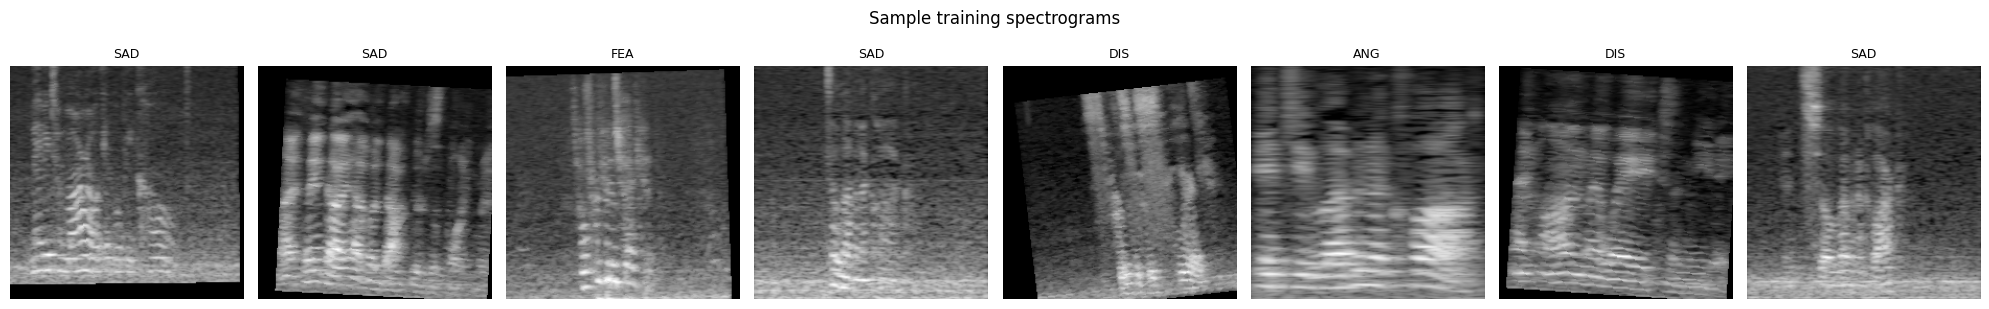

In [6]:
def denorm(tensor):
    """Reverse the 0.5/0.5 normalisation for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

images, labels = next(iter(train_loader))
n_show = min(8, len(images))

fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for i, ax in enumerate(axes):
    img = denorm(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img[:, :, 0], cmap="gray")
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample training spectrograms", y=1.02)
plt.tight_layout()
plt.show()

## 5) Model definition

Using ResNet50 pretrained on ImageNet for emotion classification.

In [7]:
import torchvision.models as models

# Load pretrained ResNet50
model = models.resnet50(weights="IMAGENET1K_V1")

# Freeze all pretrained layers by default
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Unfreeze layer3, layer4, and head for fine-tuning
for name, param in model.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Trainable parameters: 22,075,398
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [9]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc="train" if training else "eval ", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total


for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    test_loss,  test_acc  = run_epoch(test_loader,  training=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:>3}/{NUM_EPOCHS}  "
          f"train loss {train_loss:.4f}  acc {train_acc:.4f}  "
          f"| test loss {test_loss:.4f}  acc {test_acc:.4f}")

Epoch   1/50  train loss 1.3940  acc 0.4348  | test loss 1.2289  acc 0.5219


Epoch   2/50  train loss 1.1131  acc 0.5744  | test loss 1.1907  acc 0.5644


Epoch   3/50  train loss 0.9483  acc 0.6430  | test loss 1.2685  acc 0.5638


Epoch   4/50  train loss 0.8160  acc 0.6919  | test loss 1.3093  acc 0.5599


Epoch   5/50  train loss 0.7008  acc 0.7324  | test loss 1.2891  acc 0.5889


...

Epoch  46/50  train loss 0.0478  acc 0.9846  | test loss 1.7752  acc 0.6128


Epoch  47/50  train loss 0.0566  acc 0.9832  | test loss 1.6277  acc 0.6153


Epoch  48/50  train loss 0.0530  acc 0.9839  | test loss 1.6633  acc 0.6160


Epoch  49/50  train loss 0.0527  acc 0.9834  | test loss 1.6930  acc 0.6263


Epoch  50/50  train loss 0.0506  acc 0.9854  | test loss 1.6296  acc 0.6269


### Training curves

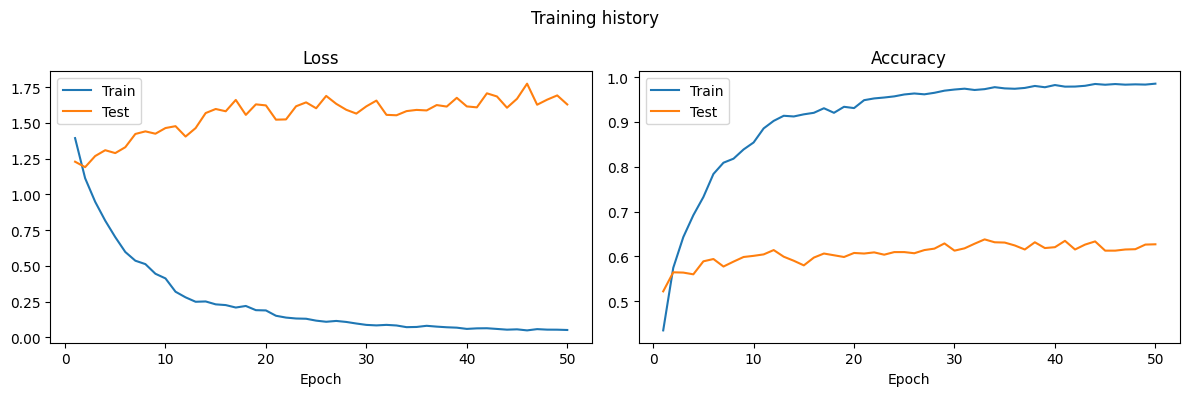

In [10]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["test_loss"],  label="Test")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="Train")
ax2.plot(epochs, history["test_acc"],  label="Test")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.suptitle("Training history")
plt.tight_layout()
plt.show()

## 7) Evaluation

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="evaluating"):
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

evaluating: 100%|██████████| 97/97 [00:36<00:00,  2.65it/s]

              precision    recall  f1-score   support

         ANG       0.72      0.72      0.72       265
         DIS       0.59      0.57      0.58       265
         FEA       0.53      0.60      0.56       265
         HAP       0.60      0.68      0.64       265
         NEU       0.73      0.64      0.68       227
         SAD       0.63      0.54      0.58       265

    accuracy                           0.63      1552
   macro avg       0.63      0.63      0.63      1552
weighted avg       0.63      0.63      0.63      1552



### Confusion matrix

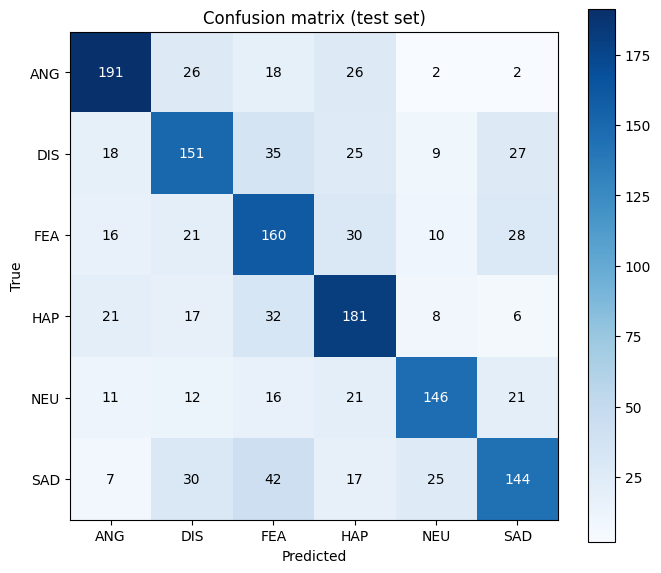

In [12]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 8) Save the model

In [13]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names":      CLASS_NAMES,
    "image_size":       IMAGE_SIZE,
    "num_classes":      NUM_CLASSES,
}, MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH.resolve()}")

Model saved to C:\Users\Jing Rong\Git\ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER\SystemCode\data\training\model.pth


### Loading the saved model (for inference)

```python
checkpoint = torch.load("model.pth", map_location="cpu")
model = models.resnet50(weights=None)  # Don't load pretrained weights
model.fc = nn.Linear(model.fc.in_features, checkpoint["num_classes"])
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
```